# Lab 2: From Raw Data to ML-Ready Data
## Data Cleaning & Exploratory Data Analysis — Telco Customer Churn

**Name:** _Nainsy chawla_

**Roll Number:** _023-24-0261_

**GitHub Repository:** _https://github.com/Nainsy-chawla/ML_Lab_Practise_

**Duration:** 3 Hours (independent, hands-on)

> This notebook is a **template**, not a tutorial. You already know Python, NumPy, Pandas, and Matplotlib from previous labs. Each section below states the objective and the questions you must answer — **you decide** which functions/plots are appropriate. Do not just run code without interpreting it: every visualization needs a written observation, and every cleaning decision needs a written justification.
>
> Fill in the empty code cells and the *Answer:* / *Observation:* placeholders directly in this notebook. Do not delete the Markdown headings — they are used for grading.

---

## Setup

Import the libraries you'll need and load the dataset. Use the Telco Customer Churn CSV provided for this lab.

In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv("telco_churn.csv")   # update path/filename if different
print(df.head())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

---

## Part 1 — The Business Problem

A telecommunications company is losing customers to competitors — this is called **customer churn**. The company wants to understand which customers are likely to leave, so it can intervene early. Before any model can be built, the raw data must be understood, audited for quality issues, and explored.

**Tasks**
1. In 2–3 sentences, state the business problem in your own words, and propose what the target variable likely is.
2. List 5 columns you expect to be useful predictors of churn, and 2 columns you expect to be useless as predictors — justify each choice in one line.
3. Write down 2 questions you personally want this data to answer about customers who churn.

**Answer 1:**
_The telecommunications company wants to understand why customers leave (churn) so it can identify customers who may leave in the future and take action to keep them. The likely target variable is Churn, because it tells us whether a customer left (Yes) or stayed (No)._

**Answer 2:**
_Useful :tenure ,contract ,internetService ,monthlycharges ,TechSupport
Useless :customerID , gender_

**Answer 3:**
_Question 1: Are customers with month-to-month contracts more likely to churn than customers with one-year or two-year contracts?

Question 2 :Are customers with higher monthly charges and shorter tenure more likely to churn?_

---

## Part 2 — Exploring the Dataset Structure

Before cleaning or analyzing anything, get an accurate picture of the dataset's shape and contents. Running a command is not the same as understanding its output — you must interpret what you see.

*Concepts/functions you may find useful:* `df.shape`, `df.columns`, `df.dtypes`, `df.info()`, `df.head()`, `df.sample(n)`, `df[col].unique()`, `df[col].nunique()`, `df.describe(include='all')`

**Tasks**
4. How many customers and how many features are in this dataset? List the numerical features and the categorical features separately.
5. Identify any column(s) that are simply identifiers rather than predictive features, and any column(s) whose data type looks wrong for what it represents.
6. Pick 3 categorical columns and report their unique values — do any contain unexpected or inconsistent categories?

In [3]:
# Task 4 — dataset shape, column names, data types

print("Dataset shape:")
print(df.shape)

print("\nColumn names:")
print(df.columns)

print("\nData types:")
print(df.dtypes)

print("\nNumerical features:")
print(df.select_dtypes(include=['number']).columns)

print("\nCategorical features:")
print(df.select_dtypes(include=['str']).columns)

Dataset shape:
(7043, 21)

Column names:
Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

Data types:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn   

In [6]:
# Task 5 — identify identifier columns / wrong data types
print("Number of unique customer IDs:", df["customerID"].nunique())
print("Number of rows:", len(df))

print("\nData type of TotalCharges:")
print(df["TotalCharges"].dtype)

print("\nSample TotalCharges values:")
print(df["TotalCharges"].head())

Number of unique customer IDs: 7043
Number of rows: 7043

Data type of TotalCharges:
str

Sample TotalCharges values:
0      29.85
1     1889.5
2     108.15
3    1840.75
4     151.65
Name: TotalCharges, dtype: str


In [7]:
# Task 6 — unique values in 3 categorical columns

print("Gender unique values:")
print(df["gender"].unique())

print("\nContract unique values:")
print(df["Contract"].unique())

print("\nInternetService unique values:")
print(df["InternetService"].unique())

Gender unique values:
<ArrowStringArray>
['Female', 'Male']
Length: 2, dtype: str

Contract unique values:
<ArrowStringArray>
['Month-to-month', 'One year', 'Two year']
Length: 3, dtype: str

InternetService unique values:
<ArrowStringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str


**Observations (Part 2):**
_(summarize what you found — numerical features, categorical features, suspicious columns, etc.)_

 Task 4: The dataset contains 7,043 customers and 21 columns.
  The numerical features are SeniorCitizen, tenure, and MonthlyCharges,
 while the remaining columns are categorical/string features.

 Task 5: customerID is an identifier because all 7,043 customers have unique IDs.
    TotalCharges is stored as a string (str), even though it represents numerical charges, so its data type needs to be corrected later.

 Task 6: The selected categorical columns (gender, Contract, and InternetService) contain expected and consistent values.
        No unexpected or inconsistent categories were found.

## Part 3 — Investigating Data Quality

A dataset can look clean at a glance and still hide serious problems. You must actively search for missing values, duplicates, and suspicious values rather than assume there are none.

*Concepts/functions you may find useful:* `df.isnull().sum()`, `df.isnull().mean()*100`, `df.duplicated().sum()`, `df['id_col'].duplicated().sum()`, `df[col].value_counts()`

**Tasks**
7. Report missing values as both a count and a percentage per column. Which missing-value problems do you think require action, and which don't? Justify your reasoning.
8. Check for duplicate rows and duplicate customer IDs separately — are they the same issue or different issues?
9. Find at least one column with a suspicious, invalid, or inconsistently formatted value, and describe how you found it.

In [8]:
# Task 7 — missing values: count and percentage per column
missing_count = df.isnull().sum()
missing_percentage = df.isnull().mean() * 100

missing_summary = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percentage": missing_percentage
})

print(missing_summary)

                  Missing Count  Missing Percentage
customerID                    0                 0.0
gender                        0                 0.0
SeniorCitizen                 0                 0.0
Partner                       0                 0.0
Dependents                    0                 0.0
tenure                        0                 0.0
PhoneService                  0                 0.0
MultipleLines                 0                 0.0
InternetService               0                 0.0
OnlineSecurity                0                 0.0
OnlineBackup                  0                 0.0
DeviceProtection              0                 0.0
TechSupport                   0                 0.0
StreamingTV                   0                 0.0
StreamingMovies               0                 0.0
Contract                      0                 0.0
PaperlessBilling              0                 0.0
PaymentMethod                 0                 0.0
MonthlyCharg

In [9]:
# Task 8 — duplicate rows vs duplicate IDs

print("Duplicate rows:", df.duplicated().sum())

print("Duplicate customer IDs:", df["customerID"].duplicated().sum())

Duplicate rows: 0
Duplicate customer IDs: 0


In [10]:
# Task 9 — investigate a suspicious / invalid value

print("TotalCharges data type:")
print(df["TotalCharges"].dtype)

total_charges_numeric = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

print("\nInvalid TotalCharges values:",
      total_charges_numeric.isnull().sum())

TotalCharges data type:
str

Invalid TotalCharges values: 11


**Answer 7 (which missing-value problems need action, and why):**
_(your answer here)_

**Answer 8 (duplicate rows vs duplicate IDs — same issue or different?):**
_(your answer here)_

**Answer 9 (suspicious value found and how):**
_(your answer here)_

Answer 7

Most columns have no missing values. However, missing or blank values in important numerical columns such as TotalCharges would require action because they could affect analysis and machine learning. Columns with no missing values do not require any missing-value treatment.

Answer 8

Duplicate rows and duplicate customer IDs are different issues. Duplicate rows mean the entire record is repeated, while duplicate customer IDs mean the same customer identifier appears more than once. Therefore, they should be checked separately.

Answer 9

TotalCharges was found to be suspicious because it is stored as a string even though it represents numerical charges. I investigated it by using pd.to_numeric() with errors="coerce" to identify values that could not be converted into numbers. Any values converted to NaN are invalid or blank entries that need to be handled.---

## Part 4 — Data Cleaning Decisions

Cleaning is a series of justified decisions, not a fixed recipe. For every issue you fix, you must be able to explain why you chose that method over an alternative.

*Concepts/functions you may find useful:* `pd.to_numeric(s, errors='coerce')`, `df.fillna(value)`, `df.dropna()`, `df.drop_duplicates()`, `df[col].str.strip()`, `df.astype(dtype)`

**Tasks**
10. For every data-quality issue you found in Part 3, record: Problem → Decision → Method Used → Reason.
11. Apply your cleaning decisions to produce an intermediate cleaned dataframe, and confirm (with code output) that each issue is actually resolved.

**Task 10 — Cleaning Decision Log**

| Problem | Decision | Method Used | Reason |
|---|---|---|---|
| _e.g. TotalCharges stored as text_ | _Convert it to numeric_ | _pd.to_numeric()_ | _TotalCharges represents an amount, so it should be numerical for analysis._ |
| _Blank/invalid values in TotalCharges_ | _values to missing (NaN)_ | _pd.to_numeric(errors='coerce')_ | _This safely identifies values that cannot be converted to numbers._ |
| _Duplicate rows_ | _Remove duplicate rows if any exist_ | _df.drop_duplicates()_ | _Duplicate records can affect analysis and give some customers more weight than they should have._ |
| _Duplicate customer IDs_ | _Investigate before removing...Investigate before removing_ | _df["customerID"].duplicated()_ | _A repeated ID does not automatically mean the entire record is wrong; we should not delete data without checking._ |                                                                                                                  

In [11]:
# Task 11 — apply your cleaning decisions here

df_clean = df.copy()

# Convert TotalCharges to numeric
df_clean["TotalCharges"] = pd.to_numeric(
    df_clean["TotalCharges"],
    errors="coerce"
)

# Remove completely duplicated rows
df_clean = df_clean.drop_duplicates()

print("Cleaning completed.")

Cleaning completed.


In [12]:
# Task 11 (continued) — confirm each issue is resolved (e.g. re-check isnull().sum(), duplicated().sum(), dtypes)

print("Missing values:")
print(df_clean.isnull().sum())

print("\nDuplicate rows:")
print(df_clean.duplicated().sum())

print("\nDuplicate customer IDs:")
print(df_clean["customerID"].duplicated().sum())

print("\nData types:")
print(df_clean.dtypes)

Missing values:
customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

Duplicate rows:
0

Duplicate customer IDs:
0

Data types:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract 

---

## Part 5 — Univariate EDA

Look at individual variables in isolation before looking at relationships. Every chart must be followed by a written interpretation — a graph with no explanation earns no credit.

*Concepts/functions you may find useful:* `df[col].plot(kind='hist')` / `plt.hist()`, `df.boxplot(column=col)`, `df[col].value_counts().plot(kind='bar')`

**Tasks**
12. Visualize the distribution of at least 2 numerical features and 2 categorical features. For each chart, write 1–2 sentences on what you learned.
13. Do any numerical features show outliers or a skewed distribution? What might explain this?

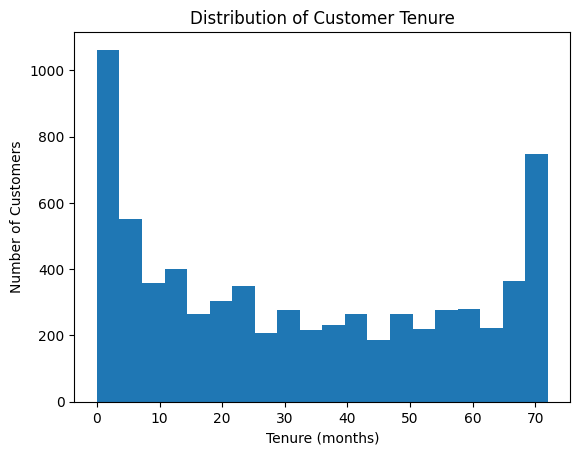

In [14]:
# Task 12 — numerical feature 1: distribution plot
import matplotlib.pyplot as plt

df_clean["tenure"].plot(kind="hist", bins=20)

plt.title("Distribution of Customer Tenure")
plt.xlabel("Tenure (months)")
plt.ylabel("Number of Customers")
plt.show()

**Observation:** _The histogram shows how long customers have stayed with the company. Customers are spread across different tenure levels, with noticeable numbers of both newer and long-term customers._

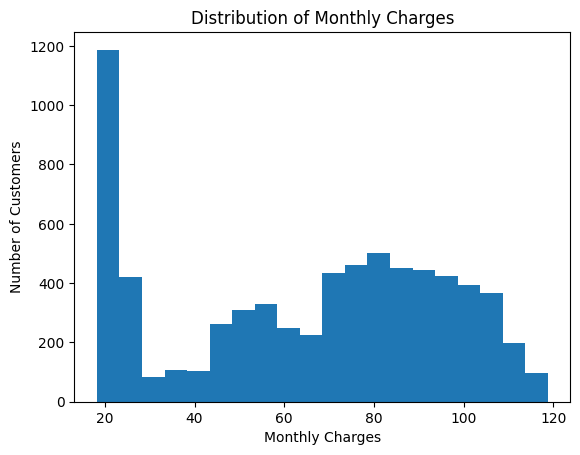

In [15]:
# Task 12 — numerical feature 2: distribution plot
df_clean["MonthlyCharges"].plot(kind="hist", bins=20)

plt.title("Distribution of Monthly Charges")
plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")
plt.show()

**Observation:** _The monthly charges are spread across different price levels, with many customers paying moderate monthly charges. There are also some customers with relatively high monthly charges._

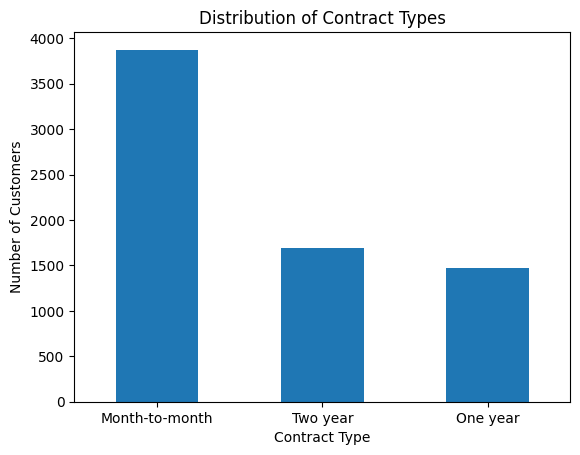

In [16]:
# Task 12 — categorical feature 1: distribution plot
df_clean["Contract"].value_counts().plot(kind="bar")

plt.title("Distribution of Contract Types")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()

**Observation:** _Most of the customers have month-to-month contracts. One-year contracts are less common, and two-year contracts have the fewest customers._

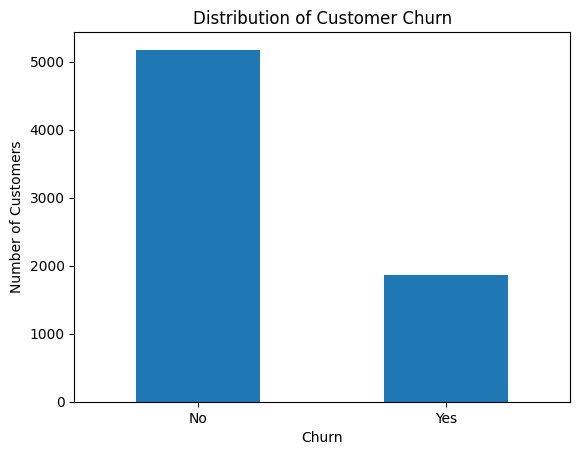

In [17]:
# Task 12 — categorical feature 2: distribution plot
df_clean["Churn"].value_counts().plot(kind="bar")

plt.title("Distribution of Customer Churn")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()

**Observation:** _Most customers did not leave the company, while a smaller number of customers churned. This shows that the dataset has more customers who stayed than customers who left._

**Answer 13 (outliers / skew and possible explanation):**
_Some numerical features, especially MonthlyCharges and TotalCharges, may have a few high values that look like outliers. TotalCharges can be higher for customers who have stayed longer, while high MonthlyCharges may be due to customers using more or expensive services._

---

## Part 6 — Target Variable Analysis

The `Churn` column is what you will eventually predict. Before Lab 3, you need to understand its distribution — this has direct consequences for how a model should later be trained and evaluated.

*Concepts/functions you may find useful:* `df['Churn'].value_counts()`, `df['Churn'].value_counts(normalize=True)`

**Tasks**
14. Report the number and percentage of churned vs. non-churned customers. Is the target balanced or imbalanced?
15. In 2–3 sentences, explain why class imbalance might matter when a classification model is trained later — do not describe how to fix it, just why it matters.

In [18]:
# Task 14 — churn counts and percentages
print("Churn counts:")
print(df_clean["Churn"].value_counts())

print("\nChurn percentages:")
print(df_clean["Churn"].value_counts(normalize=True) * 100)

Churn counts:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn percentages:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


**Answer 14 (balanced or imbalanced?):**
_There are 5,174 customers who did not churn and 1,869 customers who churned. This is about 73.5% non-churned and 26.5% churned customers. Therefore, the target variable is imbalanced, because the two classes are not present in similar proportions._

**Answer 15 (why imbalance might matter later):**
_Class imbalance matters because the model will see many more non-churned customers than churned customers. This may make the model better at predicting the majority class while not performing as well when identifying customers who are actually going to churn._

---

## Part 7 — Bivariate Analysis: Features vs. Churn

Now connect individual features to the target. You choose the appropriate visualization or summary for each feature type — a categorical feature is not explored the same way as a numerical one.

*Concepts/functions you may find useful:* `pd.crosstab(df[col], df['Churn'], normalize='index')`, `df.groupby(col)['Churn']...`, `sns.boxplot(x='Churn', y=col, data=df)`

**Tasks**
16. Investigate at least 2 categorical features (e.g. Contract, InternetService, PaymentMethod) against Churn. For each, record: Observation / Evidence / Possible Explanation.
17. Investigate at least 2 numerical features (e.g. tenure, MonthlyCharges) against Churn using the same Observation / Evidence / Possible Explanation format.

In [19]:
# Task 16 — categorical feature 1 vs Churn

contract_churn = pd.crosstab(
    df_clean["Contract"],
    df_clean["Churn"],
    normalize="index"
) * 100

print(contract_churn)

Churn                  No        Yes
Contract                            
Month-to-month  57.290323  42.709677
One year        88.730482  11.269518
Two year        97.168142   2.831858


**Observation:** _Customers with month-to-month contracts seem much more likely to churn than customers with one-year or two-year contracts._
**Evidence:** _The churn percentage for month-to-month customers is much higher than for customers on one-year and two-year contracts._
**Possible Explanation:** _Month-to-month customers have less commitment, so it may be easier for them to leave the company if they are unhappy with the service or prices._

In [21]:
# Task 16 — categorical feature 2 vs Churn

internet_churn = pd.crosstab(
    df_clean["InternetService"],
    df_clean["Churn"],
    normalize="index"
) * 100

print(internet_churn)

Churn                   No        Yes
InternetService                      
DSL              81.040892  18.959108
Fiber optic      58.107235  41.892765
No               92.595020   7.404980


**Observation:** _Churn is different for customers using different types of internet services. Fiber optic customers appear to have a higher churn rate than DSL and customers without internet service._
**Evidence:** _The percentage of Yes in the Churn column is higher for Fiber optic customers compared with the other internet service categories._
**Possible Explanation:** _Fiber optic service may be more expensive, or customers using it may have higher expectations about their internet service, which could make them more likely to leave if they are dissatisfied._

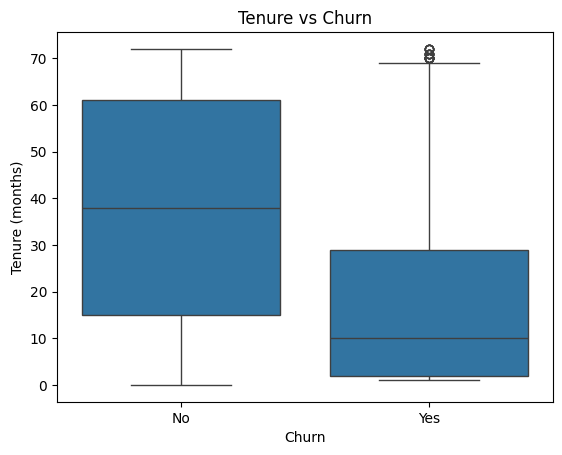

In [22]:
# Task 17 — numerical feature 1 vs Churn

sns.boxplot(x="Churn", y="tenure", data=df_clean)

plt.title("Tenure vs Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure (months)")
plt.show()

**Observation:** _Customers who churned generally have lower tenure than customers who stayed._
**Evidence:** _In the boxplot, the median tenure for customers who churned is lower than the median tenure for customers who did not churn._
**Possible Explanation:** _New customers may be more likely to leave because they have had less time to become loyal to the company or may leave if they are not satisfied with the service._

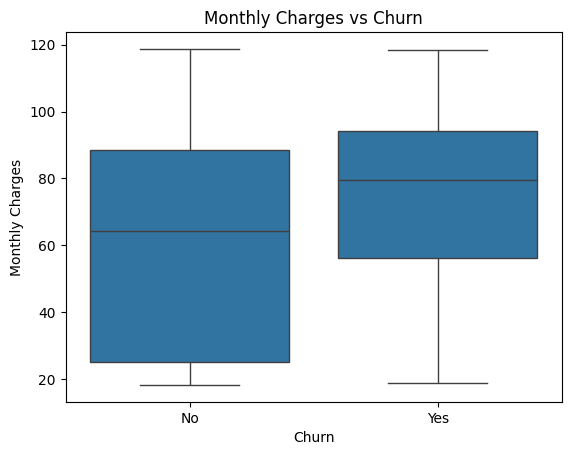

In [23]:
# Task 17 — numerical feature 2 vs Churn
sns.boxplot(x="Churn", y="MonthlyCharges", data=df_clean)

plt.title("Monthly Charges vs Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.show()

**Observation:** _Customers who churned generally have higher monthly charges than customers who stayed_
**Evidence:** _The boxplot shows that the median MonthlyCharges for churned customers is higher than the median for customers who did not churn._
**Possible Explanation:** _Customers paying higher monthly charges may feel that the service is too expensive, which could make them more likely to leave._

---

## Part 8 — Correlation & Feature Relationships

Numerical features can be related to each other, not just to the target. Strongly correlated features can cause redundancy problems later, so it's worth knowing about them now.

*Concepts/functions you may find useful:* `df.corr(numeric_only=True)`, `sns.heatmap(corr_matrix, annot=True)`

**Tasks**
18. Compute and visualize the correlation matrix of the numerical features. Which pairs appear most correlated?
19. Does correlation imply causation here? Could any highly correlated features cause problems for a future model? Answer in 2–3 sentences.

In [ ]:
# Task 18 — correlation matrix and heatmap

corr_matrix = df_clean.corr(numeric_only=True)

print(corr_matrix)

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")

plt.title("Correlation Matrix of Numerical Features")
plt.show()

**Answer 18 (most correlated pairs):**
_tenure and TotalCharges have the strongest positive correlation. This makes sense because customers who have stayed longer generally accumulate higher total charges. MonthlyCharges also has a positive relationship with TotalCharges, although it is weaker than the relationship between tenure and TotalCharges._

**Answer 19 (correlation vs. causation; potential problems):**
_Correlation does not mean that one variable causes another. For example, tenure and TotalCharges are highly correlated because longer-term customers have more time to accumulate charges, but this does not mean that tenure directly causes higher charges. Highly correlated features can also provide similar information to a future model and may cause redundancy._

---

## Part 9 — Data Leakage Awareness

In Lab 3 you will train a classifier. Before that, you must check whether any column contains information that would not realistically be available at the moment of prediction — using such a column would make a model look artificially accurate.

**Tasks**
20. Inspect the columns for anything that looks like it could only be known after a customer has already churned, or that is purely an identifier. List any suspects and explain your reasoning.
21. In 2–3 sentences, explain what would go wrong if such a column were left in the model's input features.

**Answer 20 (suspect columns and reasoning):**
_customerID is a suspect because it is only an identifier and does not contain useful information about the customer's behavior. I did not find any other column that clearly contains information that would only be known after churn; the other columns describe the customer's services, charges, contract, and account information._

**Answer 21 (what would go wrong):**
_If we use such columns in the model, the model may learn information that would not be available when predicting churn. This can make the model look more accurate than it actually is and give wrong results for new customers._

---

## Part 10 — ML-Readiness Checklist

Summarize every column's fate in a single table. This is the bridge between EDA and modeling — Lab 3 will use this table directly.

**Task**
22. Complete the ML-readiness table for **every** column in the dataset.
    
| Column | Type | Role | Action | Reason |
|---|---|---|---|---|
| customerID | Identifier | — | Remove | It only identifies the customer and does not help predict churn. |
| gender | Categorical | Feature | Keep | It may help identify differences in churn between genders. |
| SeniorCitizen | Numerical | Feature | Keep | It shows whether the customer is a senior citizen and may be related to churn. |
| Partner | Categorical | Feature | Keep | Having a partner may affect customer behavior and churn. |
| Dependents | Categorical | Feature | Keep | Having dependents may affect the customer's decision to stay or leave. |
| tenure | Numerical | Feature | Keep | It shows how long the customer has stayed with the company. |
| PhoneService | Categorical | Feature | Keep | Phone service may be related to customer usage and churn. |
| MultipleLines | Categorical | Feature | Keep | The type of phone service may provide useful information about churn. |
| InternetService | Categorical | Feature | Keep | Different internet services may have different churn rates. |
| OnlineSecurity | Categorical | Feature | Keep | Security service usage may be related to customer satisfaction. |
| OnlineBackup | Categorical | Feature | Keep | Backup service usage may provide useful information about the customer. |
| DeviceProtection | Categorical | Feature | Keep | Device protection may be related to customer needs and churn. |
| TechSupport | Categorical | Feature | Keep | Technical support may affect customer satisfaction and churn. |
| StreamingTV | Categorical | Feature | Keep | Streaming TV usage may show customer preferences. |
| StreamingMovies | Categorical | Feature | Keep | Streaming movie usage may show customer preferences. |
| Contract | Categorical | Feature | Keep | Contract type has a strong relationship with churn. |
| PaperlessBilling | Categorical | Feature | Keep | Billing preference may be related to customer behavior. |
| PaymentMethod | Categorical | Feature | Keep | Payment method may be related to churn behavior. |
| MonthlyCharges | Numerical | Feature | Keep | Higher monthly charges may make customers more likely to leave. |
| TotalCharges | Numerical | Feature | Keep | It shows the total amount charged to the customer and can provide useful information. |
| Churn | Categorical | Target | Keep | This is the variable that the model will predict. |
_(Add one row per remaining column — copy the pattern above.)_

---

## Part 11 — Building the Clean Dataset

Bring together every cleaning decision into one final dataframe, `clean_df`, that Lab 3 can load directly.

> Do **not** split into train/test, encode categorical variables, or train any model — that happens in Lab 3.

**Tasks**
23. Produce `clean_df` with correct data types, missing values handled, duplicates handled, and irrelevant identifier columns removed where justified. Save it (e.g. `clean_churn.csv`) alongside your notebook.
24. Print `df.info()` (or equivalent) for `clean_df` as final proof that every issue identified earlier has been resolved.

In [4]:
# Task 23 — assemble clean_df from your cleaning decisions
clean_df = df.copy()

# ... apply your cleaning steps here ...
clean_df["TotalCharges"] = pd.to_numeric(
    clean_df["TotalCharges"],
    errors="coerce"
)

clean_df = clean_df.dropna(subset=["TotalCharges"])

clean_df = clean_df.drop_duplicates()

clean_df = clean_df.drop(columns=["customerID"])

# Save the cleaned dataset
clean_df.to_csv("clean_churn.csv", index=False)
print("Clean dataset shape:", clean_df.shape)

Clean dataset shape: (7032, 20)


In [5]:
# Task 24 — final proof: info() / isnull().sum() / duplicated().sum() on clean_df

print("Dataset information:")
clean_df.info()

print("\nMissing values:")
print(clean_df.isnull().sum())

print("\nDuplicate rows:")
print(clean_df.duplicated().sum())

Dataset information:
<class 'pandas.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   str    
 1   SeniorCitizen     7032 non-null   int64  
 2   Partner           7032 non-null   str    
 3   Dependents        7032 non-null   str    
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   str    
 6   MultipleLines     7032 non-null   str    
 7   InternetService   7032 non-null   str    
 8   OnlineSecurity    7032 non-null   str    
 9   OnlineBackup      7032 non-null   str    
 10  DeviceProtection  7032 non-null   str    
 11  TechSupport       7032 non-null   str    
 12  StreamingTV       7032 non-null   str    
 13  StreamingMovies   7032 non-null   str    
 14  Contract          7032 non-null   str    
 15  PaperlessBilling  7032 non-null   str    
 16  PaymentMethod     7032 non-null   str

---

## Part 12 — Key Findings & Final Reflection

Step back from the code and summarize what you actually learned about this dataset and this problem.

**Task 25 — Five Important Findings**

Repeat this block for each of your five findings.

**Finding 1**
- Observation: _Most customers did not churn, but a noticeable number of customers left._
- Evidence: _5,174 customers stayed, while 1,869 customers churned._
- Interpretation: _The target variable is imbalanced, so predicting churn correctly will be important later._

**Finding 2**
- Observation: _Customers with month-to-month contracts are more likely to churn._
- Evidence: _The churn rate for month-to-month customers was much higher than for one-year and two-year contract customers._
- Interpretation: _Customers with short-term contracts may find it easier to leave the company._

**Finding 3**
- Observation: _Customers with shorter tenure are more likely to churn._
- Evidence: _The boxplot showed that churned customers generally had lower tenure than customers who stayed._
- Interpretation: _Newer customers may not be as loyal to the company and may leave more easily._

**Finding 4**
- Observation: _Customers with higher monthly charges seem more likely to churn._
- Evidence: _The boxplot showed a higher median MonthlyCharges for customers who churned._
- Interpretation: _Higher monthly costs may make customers more likely to leave if they feel the service is too expensive._

**Finding 5**
- Observation: _TotalCharges was strongly related to tenure._
- Evidence: _The correlation matrix showed a strong positive correlation between tenure and TotalCharges._
- Interpretation: _Customers who stay longer have more time to accumulate higher total charges, so these two features contain some similar information._

---

**Task 26 — Final Reflection Questions**

1. What was the most important data-quality issue you found?

   _The most important issue was TotalCharges being stored as a string instead of a number. It also had 11 blank or invalid values that needed to be handled._
2. What was the most interesting pattern you discovered?

   _The most interesting pattern was that customers with month-to-month contracts were much more likely to churn than customers with longer contracts._
3. Which feature seems most useful for predicting churn?

   _Contract seems to be one of the most useful features because the churn rate was very different between contract types._
4. Which feature should probably not be used, and why?

   _customerID should not be used because it is only an identifier and does not give useful information about why a customer may churn._
5. What preprocessing will be required before ML modeling (conceptually — do not implement it)?

   _Categorical features will need to be converted into a format that the ML model can understand. The data may also need feature scaling depending on the model, and the target variable will need to be prepared for classification._
6. What would you do next if you had another 3 hours?

   _I would explore more features against churn and look for stronger patterns. I would also try different ML models later and compare their performance to see which one predicts churn better._

---

## Bonus Tasks (Optional)

- Create one additional meaningful visualization not required above.
- Investigate a surprising customer subgroup you didn't expect to find.
- Calculate churn rate across a combination of 2+ customer segments at once.
- Identify one possible feature-engineering opportunity for Lab 3.
- Identify one possible source of bias in this dataset.

In [ ]:
# Bonus — optional exploration


---

## Submission Checklist

Before submitting, confirm you have:

- [Y] Completed all 26 tasks above, with written interpretation for every chart and decision
- [Y] A working `clean_df`, saved as `clean_churn.csv`
- [Y] A completed ML-readiness table (Part 10) covering every column
- [Y] Five Key Findings written (Part 12)
- [Y] Answered all six Final Reflection questions
- [Y] Committed and pushed this notebook + `clean_churn.csv` to your GitHub repository
- [Y] Added your GitHub repository link at the top of this notebook